# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

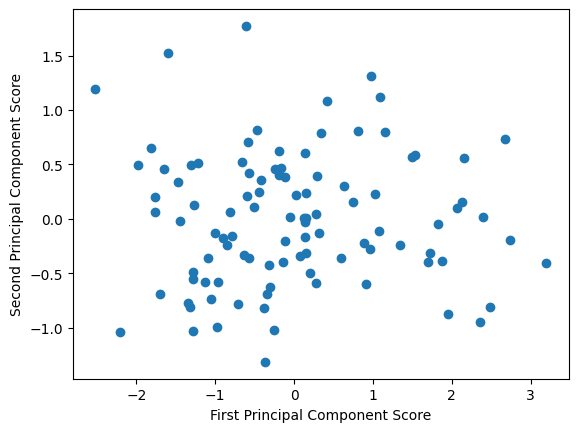

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The three outliers in the upper-left corner of the PCA scatter plot have low first principal component (PC1) scores and high second principal component (PC2) scores. A low PC1 score indicates that these observations have relatively low overall values across all three series, since PC1 primarily captures the common variation shared by series_1, series_2, and series_3. In contrast, a high PC2 score reflects a strong deviation from that shared pattern. Because series_3 was constructed with substantially more noise than the other two series, PC2 is largely driven by how much series_3 differs from series_1 and series_2. Therefore, these outliers likely have relatively low values of series_1 and series_2, but comparatively higher values of series_3 than would be expected given the first two. It is much harder to say anything specific about the relationship between series_1 and series_2 for these points because the two variables are extremely similar by construction as series_2 is just series_1 with a small amount of noise, so they are highly correlated and contribute almost identically to PC1. As a result, PCA does not strongly distinguish between them, and any differences between the two are pushed into a minor component that is not visible in this two-dimensional plot. This makes it nearly impossible to infer their relative values from the graph. Overall, the PCA plot is useful for reducing dimensionality and highlighting general patterns, such as the dominant shared signal (PC1) and the additional variability introduced by series_3 (PC2), as well as making outliers easy to spot. However, this comes at the cost of interpretability, since the principal components are linear combinations of the original variables, and some detailed relationships—especially between highly correlated variables like series_1 and series_2—are obscured.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [3]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import kagglehub

# -----------------------------
# LOAD DATA 
# -----------------------------
dataset_path = kagglehub.dataset_download("ammaraahmad/us-ecommerce-record-2020")

csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
csv_file = os.path.join(dataset_path, csv_files[0])

df = pd.read_csv(csv_file, encoding='ISO-8859-1')

print("Shape:", df.shape)
print(df.head())

Shape: (3312, 19)
  Order Date  Row ID        Order ID       Ship Mode Customer ID      Segment  \
0   01-01-20     849  CA-2017-107503  Standard Class    GA-14725     Consumer   
1   01-01-20    4010  CA-2017-144463  Standard Class    SC-20725     Consumer   
2   01-01-20    6683  CA-2017-154466     First Class    DP-13390  Home Office   
3   01-01-20    8070  CA-2017-151750  Standard Class    JM-15250     Consumer   
4   01-01-20    8071  CA-2017-151750  Standard Class    JM-15250     Consumer   

         Country         City       State  Postal Code   Region  \
0  United States       Lorain        Ohio        44052     East   
1  United States  Los Angeles  California        90036     West   
2  United States     Franklin   Wisconsin        53132  Central   
3  United States   Huntsville       Texas        77340  Central   
4  United States   Huntsville       Texas        77340  Central   

        Product ID         Category Sub-Category  \
0  FUR-FU-10003878        Furniture  Fur

In [4]:
# -----------------------------
# CLEAN + SELECT NUMERIC DATA
# -----------------------------
# Keep useful numeric columns (edit if needed)
numeric_cols = ['Sales', 'Profit', 'Quantity', 'Discount']
df_numeric = df[numeric_cols].dropna()

print(df_numeric.describe())

              Sales       Profit     Quantity     Discount
count   3312.000000  3312.000000  3312.000000  3312.000000
mean     221.381418    28.212340     3.766908     0.156467
std      585.257531   241.864342     2.221776     0.207429
min        0.444000 -3839.990400     1.000000     0.000000
25%       17.018000     1.763200     2.000000     0.000000
50%       53.810000     8.296800     3.000000     0.200000
75%      205.105700    28.315125     5.000000     0.200000
max    13999.960000  6719.980800    14.000000     0.800000


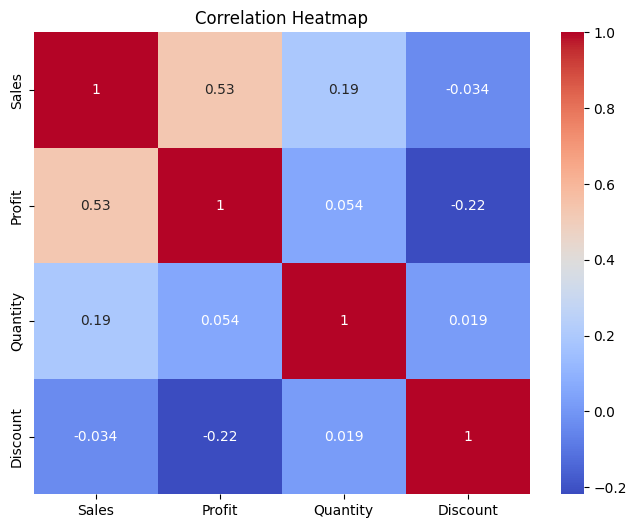

In [5]:
# -----------------------------
# 1. HEATMAP
# -----------------------------
plt.figure(figsize=(8,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

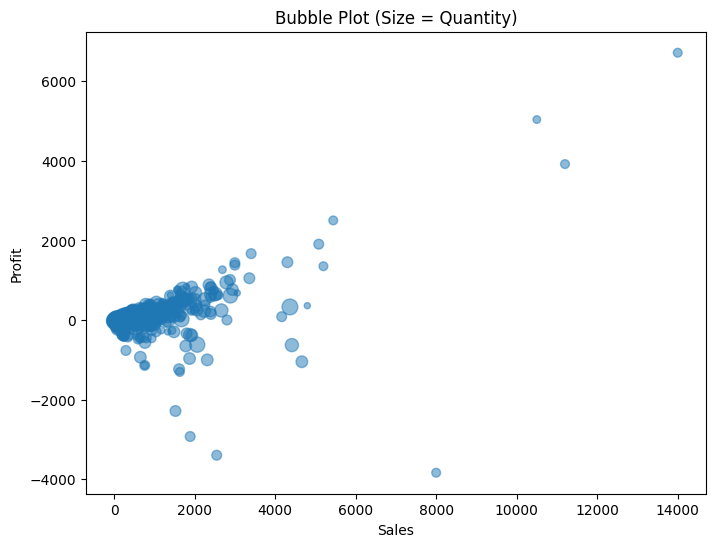

In [6]:
# -----------------------------
# 2. BUBBLE PLOT
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(df_numeric['Sales'],
            df_numeric['Profit'],
            s=df_numeric['Quantity']*10,
            alpha=0.5)

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Bubble Plot (Size = Quantity)")
plt.show()

Explained variance ratio:
[9.00876820e-01 9.91112592e-02 1.18198656e-05 1.01135077e-07]


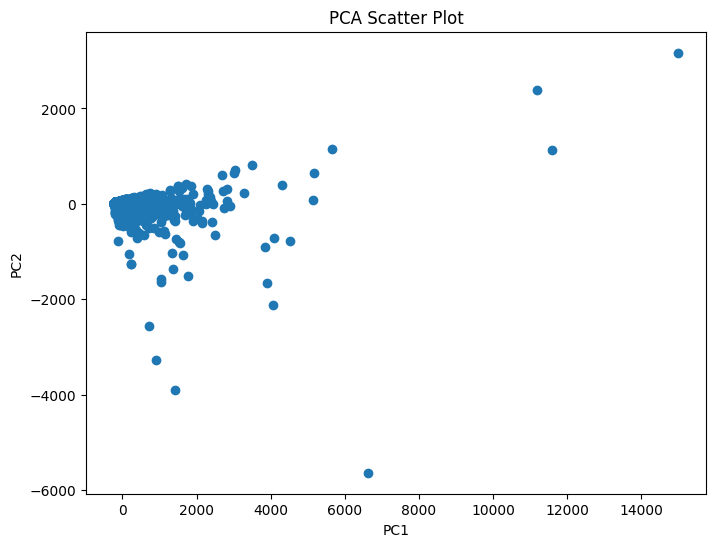

Variance captured by first PC: 0.9008768198447524


In [7]:
# -----------------------------
# 3. PCA
# -----------------------------
# Center data
df_centered = df_numeric - df_numeric.mean()

pca = PCA()
pca.fit(df_centered)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

# Transform data
pc_scores = pca.transform(df_centered)

plt.figure(figsize=(8,6))
plt.scatter(pc_scores[:,0], pc_scores[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatter Plot")
plt.show()

print("Variance captured by first PC:",
      pca.explained_variance_ratio_[0])

In [8]:
# -----------------------------
# 4. LINEAR REGRESSION
# -----------------------------
# Predict Profit using other features
X = df_numeric[['Sales', 'Quantity', 'Discount']]
y = df_numeric['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R^2 score:", r2_score(y_test, y_pred))

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coeff_df)

R^2 score: 0.2982273531193569
    Feature  Coefficient
0     Sales     0.076083
1  Quantity     3.068413
2  Discount  -248.457164


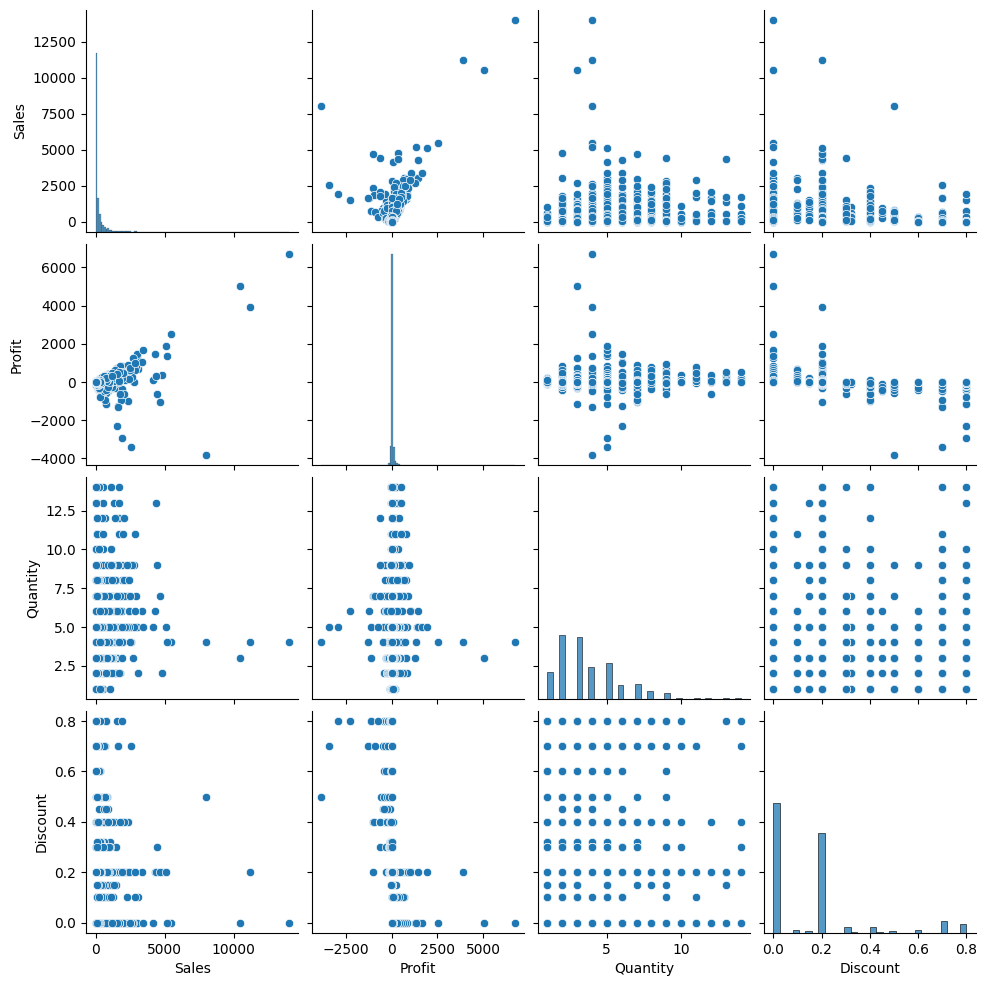

In [9]:
# -----------------------------
# 5. PAIRPLOT
# -----------------------------
sns.pairplot(df_numeric)
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

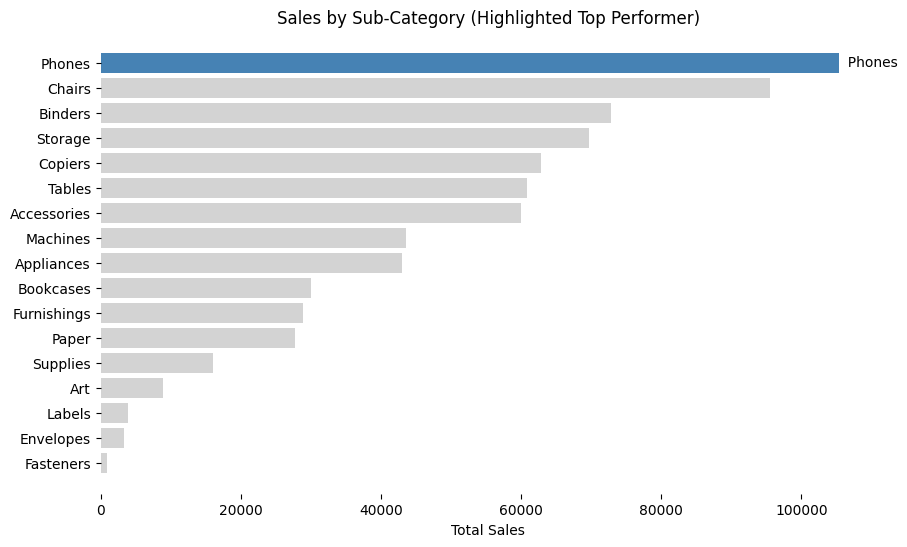

In [10]:
# Use existing dataframe (df)
# Group by Sub-Category (common column in this dataset)
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values()

# Convert to DataFrame
plot_df = subcat_sales.reset_index()

# Highlight Sub-Category
highlight = plot_df.iloc[-1]['Sub-Category']  # highest sales

# Create color list
colors = ['lightgray' if cat != highlight else 'steelblue'
          for cat in plot_df['Sub-Category']]

# Plot
plt.figure(figsize=(10,6))
plt.barh(plot_df['Sub-Category'], plot_df['Sales'], color=colors)

# Labels and title
plt.xlabel("Total Sales")
plt.ylabel("")
plt.title("Sales by Sub-Category (Highlighted Top Performer)")

# Remove clutter (Storytelling with Data style)
sns.despine(left=True, bottom=True)

# Annotate highlighted bar
for i, (value, name) in enumerate(zip(plot_df['Sales'], plot_df['Sub-Category'])):
    if name == highlight:
        plt.text(value, i, f"  {name}", va='center')

plt.show()